# Week 12 - Final CNN Genre Classifier

## Project Overview

This notebook presents the final convolutional neural network (CNN) developed throughout the project.

Earlier notebooks introduced the foundations of audio processing, feature engineering, and convolutional neural networks using a reduced subset of the GTZAN dataset.

For the final model, the complete GTZAN dataset is used. This provides a more realistic evaluation scenario and represents the final outcome of the music genre classification task.

## Motivation

The feature fusion classifier achieved the highest accuracy among the classical machine learning models.

However, it relies on manually designed audio descriptors such as MFCCs, Chroma, Tonnetz, and spectral features.

The goal of this project is not only to maximize classification accuracy, but also to investigate how convolutional neural networks can learn meaningful audio representations directly from Mel-spectrograms.

Therefore, the final model of this project is an optimized CNN, which automatically learns relevant features from raw spectral representations and forms the basis for the recommendation system developed in the following notebook.

## Project Evolution

Over the course of this project, several increasingly sophisticated approaches to music genre classification were explored.

| Stage | Approach |
|--------|----------|
| Week 4 | MFCC + Random Forest |
| Week 6 | First CNN |
| Week 10 | Optimized CNN |
| Week 11 | Feature Fusion Random Forest |
| Week 12 | Final CNN |

Each iteration introduced new ideas and improvements.

The model presented in this notebook combines the most successful concepts developed throughout the project into a final architecture.

In [36]:
import copy
import numpy as np
import pandas as pd
import librosa
from pathlib import Path
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
else:
    print("CUDA is not available. Training will run on CPU.")

Using device: cpu
CUDA is not available. Training will run on CPU.


## Complete Classification Pipeline

The complete workflow can be summarized as follows:

Audio File

↓

Mel-Spectrogram

↓

Normalization

↓

CNN

↓

Softmax

↓

Predicted Genre

This notebook integrates every processing step developed throughout the project into one end-to-end classification pipeline.

## Dataset Configuration

During the development phase, a reduced subset of the GTZAN dataset was used to simplify experimentation and reduce training time.

For the final classifier, all available genres are included. This increases the difficulty of the classification task and provides a more realistic benchmark.

The resulting model represents the final classifier of the project.

In [38]:
from pathlib import Path

data_path = Path("../data/raw/gtzan/Data/genres_original")

genres = sorted([
    folder.name
    for folder in data_path.iterdir()
    if folder.is_dir()
])

print(genres)

samples_per_genre = 100

target_frames = 646
n_mels = 128
sample_rate = 22050
batch_size = 16

['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [39]:
print("Data path exists:", data_path.exists())

for genre in genres:
    genre_path = data_path / genre
    print(
        genre,
        "exists:", genre_path.exists(),
        "files:", len(list(genre_path.glob("*.wav")))
    )

Data path exists: True
blues exists: True files: 100
classical exists: True files: 100
country exists: True files: 100
disco exists: True files: 100
hiphop exists: True files: 100
jazz exists: True files: 100
metal exists: True files: 100
pop exists: True files: 100
reggae exists: True files: 100
rock exists: True files: 100


## Mel-Spectrogram Generation

Instead of manually designing audio features, the CNN receives Mel-spectrograms as input.

A Mel-spectrogram represents the energy distribution of an audio signal over time and frequency. It preserves important temporal and spectral information while transforming the audio into a two-dimensional representation that can be processed similarly to an image.

This enables the CNN to automatically learn relevant audio features during training.

In [40]:
def compute_mel_spectrogram(file_path, sr=22050, n_mels=128, target_frames=130):
    y, sr = librosa.load(file_path, sr=sr, mono=True)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=n_mels
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    if mel_db.shape[1] >= target_frames:
        mel_db = mel_db[:, :target_frames]
    else:
        pad_width = target_frames - mel_db.shape[1]
        mel_db = np.pad(
            mel_db,
            ((0, 0), (0, pad_width)),
            mode="constant"
        )

    return mel_db

## Preparing the Training Dataset

Each audio file is converted into a normalized Mel-spectrogram.

Songs that cannot be processed (for example corrupted files contained in the GTZAN dataset) are skipped automatically.

The resulting dataset consists of one Mel-spectrogram and one genre label for every successfully processed song.

In [41]:
X = []
y = []
file_names = []
skipped_files = []

for genre in genres:
    genre_path = data_path / genre
    files = list(genre_path.glob("*.wav"))[:samples_per_genre]

    for file in files:
        try:
            mel = compute_mel_spectrogram(
                file,
                sr=sample_rate,
                n_mels=n_mels,
                target_frames=target_frames
            )

            X.append(mel)
            y.append(genre)
            file_names.append(file.name)

        except Exception as e:
            skipped_files.append(file)
            print("Skipped:", file.name, "|", e)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Skipped files:", len(skipped_files))

/tmp/ipykernel_10519/3480490579.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=sr, mono=True)
/home/richard/Projects/Music-Genre-Classification-with-CNNs-and-Audio-Based-Song-Recommendation/.venv/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Skipped: jazz.00054.wav | 
X shape: (999, 128, 646)
y shape: (999,)
Skipped files: 1


## Data Normalization

Neural networks generally perform better when the input data has a consistent numerical range.

The Mel-spectrograms are therefore standardized using the global mean and standard deviation of the dataset.

This improves numerical stability during optimization and helps the network converge more reliably.

Normalization statistics are computed only from the training data and later reused for inference.

This ensures that future predictions are processed consistently with the training data.

In [42]:
X_mean = X.mean()
X_std = X.std()

X = (X - X_mean) / X_std

print("Mean after normalization:", X.mean())
print("Std after normalization:", X.std())

Mean after normalization: -1.2105759e-08
Std after normalization: 1.0


In [43]:
X = X[:, np.newaxis, :, :]

print("CNN input shape:", X.shape)

CNN input shape: (999, 1, 128, 646)


In [44]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print("Classes:", encoder.classes_)

Classes: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']


In [45]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (599, 1, 128, 646)
Validation: (200, 1, 128, 646)
Test: (200, 1, 128, 646)


## Data Augmentation

Deep learning models benefit from larger and more diverse datasets.

Instead of collecting additional recordings, artificial variations of the training data can be generated.

Small perturbations encourage the network to learn more robust representations and reduce overfitting.

In [46]:
def augment_spectrogram_batch(batch, noise_level=0.02):
    noise = noise_level * torch.randn_like(batch)
    return batch + noise

## Dataset Split

The dataset is divided into three independent subsets.

- Training set: used to optimize the CNN parameters.
- Validation set: used to monitor generalization performance during training.
- Test set: used only after training to evaluate the final model.

Separating these datasets helps prevent overly optimistic performance estimates and allows the use of early stopping.

In [47]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

## Final CNN Architecture

Compared to the previous CNN versions, the final architecture introduces several improvements.

- Additional convolutional layers increase the representational capacity of the network.
- Batch Normalization stabilizes the learning process.
- Dropout reduces overfitting.
- A deeper architecture enables the extraction of increasingly abstract audio features.

The network receives Mel-spectrograms as input and learns feature representations automatically.

In [48]:
class FinalCNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((4, 4))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## Design Decisions

The final CNN architecture was designed based on observations from previous experiments.

Several decisions were made deliberately:

- Mel-spectrograms instead of MFCCs
- deeper convolutional layers
- batch normalization
- dropout regularization
- data augmentation
- early stopping
- validation monitoring

Each component addresses a specific limitation observed in earlier notebook versions.

FinalCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=Tr

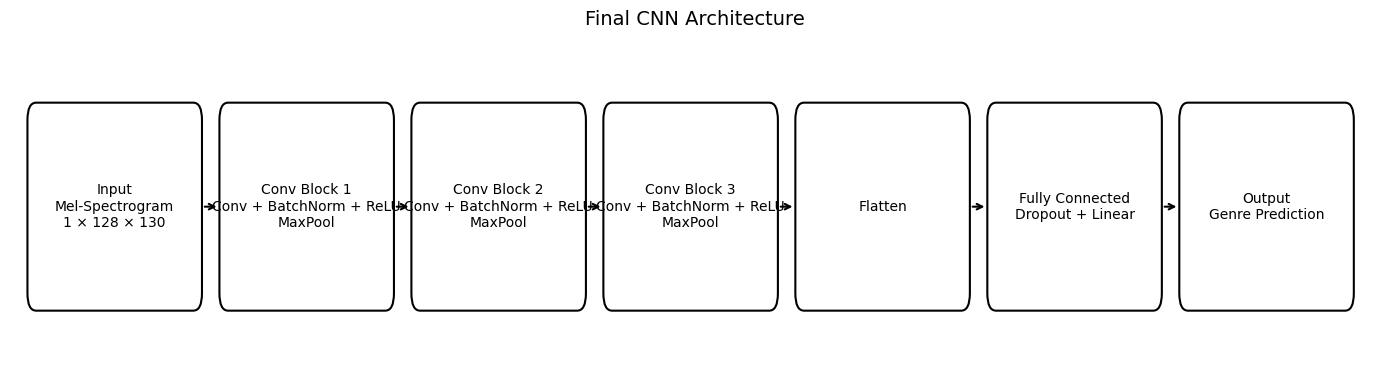

In [65]:
model = FinalCNN(num_classes=len(genres)).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

print(model)

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

def draw_cnn_architecture():
    layers = [
        ("Input\nMel-Spectrogram\n1 × 128 × 130", 0),
        ("Conv Block 1\nConv + BatchNorm + ReLU\nMaxPool", 1),
        ("Conv Block 2\nConv + BatchNorm + ReLU\nMaxPool", 2),
        ("Conv Block 3\nConv + BatchNorm + ReLU\nMaxPool", 3),
        ("Flatten", 4),
        ("Fully Connected\nDropout + Linear", 5),
        ("Output\nGenre Prediction", 6),
    ]

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.axis("off")

    box_width = 1.8
    box_height = 1.0
    y = 0.5

    for text, x in layers:
        box = FancyBboxPatch(
            (x * 2.2, y),
            box_width,
            box_height,
            boxstyle="round,pad=0.1",
            linewidth=1.5,
            facecolor="white",
            edgecolor="black"
        )
        ax.add_patch(box)

        ax.text(
            x * 2.2 + box_width / 2,
            y + box_height / 2,
            text,
            ha="center",
            va="center",
            fontsize=10
        )

        if x < len(layers) - 1:
            ax.annotate(
                "",
                xy=((x + 1) * 2.2 - 0.1, y + box_height / 2),
                xytext=(x * 2.2 + box_width + 0.1, y + box_height / 2),
                arrowprops=dict(arrowstyle="->", linewidth=1.5)
            )

    ax.set_xlim(-0.3, len(layers) * 2.2)
    ax.set_ylim(0, 2)
    plt.title("Final CNN Architecture", fontsize=14)
    plt.tight_layout()
    plt.show()

draw_cnn_architecture()

## Final CNN Architecture

The final CNN processes Mel-spectrograms as image-like inputs.

Each convolutional block extracts increasingly abstract patterns from the spectrogram.  
The fully connected layer then maps the learned representation to a genre prediction.

In [50]:
def calculate_accuracy(outputs, labels):
    preds = torch.argmax(outputs, dim=1)
    correct = (preds == labels).sum().item()
    total = labels.size(0)
    return correct / total

## Training Strategy

The final CNN combines several techniques commonly used in modern deep learning.

- Data augmentation increases robustness.
- Batch Normalization stabilizes optimization.
- Weight decay acts as regularization.
- Early stopping prevents unnecessary training once validation performance stops improving.
- The best-performing model is selected based on validation accuracy instead of the final epoch.

Together, these techniques improve both training stability and generalization performance.

In [51]:
num_epochs = 50

patience = 7
epochs_without_improvement = 0

best_val_accuracy = 0.0
best_model_state = None
best_epoch = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):

    model.train()

    running_train_loss = 0
    running_train_acc = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # simple augmentation only during training
        X_batch = augment_spectrogram_batch(X_batch, noise_level=0.01)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        running_train_acc += calculate_accuracy(outputs, y_batch)

    avg_train_loss = running_train_loss / len(train_loader)
    avg_train_acc = running_train_acc / len(train_loader)

    model.eval()

    running_val_loss = 0
    running_val_acc = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            running_val_loss += loss.item()
            running_val_acc += calculate_accuracy(outputs, y_batch)

    avg_val_loss = running_val_loss / len(val_loader)
    avg_val_acc = running_val_acc / len(val_loader)

    scheduler.step(avg_val_acc)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(avg_train_acc)
    val_accuracies.append(avg_val_acc)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Train Acc: {avg_train_acc:.4f} | "
        f"Val Acc: {avg_val_acc:.4f}"
    )

    if avg_val_acc > best_val_accuracy:
        best_val_accuracy = avg_val_acc
        best_model_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1
        epochs_without_improvement = 0

        print(f"New best model! Validation Accuracy: {best_val_accuracy:.4f}")

    else:
        epochs_without_improvement += 1
        print(f"No improvement ({epochs_without_improvement}/{patience})")

    if epochs_without_improvement >= patience:
        print("Early stopping triggered.")
        break

Epoch 1/50 | Train Loss: 1.9080 | Val Loss: 1.6479 | Train Acc: 0.3186 | Val Acc: 0.3750
New best model! Validation Accuracy: 0.3750
Epoch 2/50 | Train Loss: 1.4385 | Val Loss: 1.4428 | Train Acc: 0.4730 | Val Acc: 0.4760
New best model! Validation Accuracy: 0.4760
Epoch 3/50 | Train Loss: 1.3076 | Val Loss: 1.3103 | Train Acc: 0.5324 | Val Acc: 0.5096
New best model! Validation Accuracy: 0.5096
Epoch 4/50 | Train Loss: 1.2383 | Val Loss: 1.2420 | Train Acc: 0.5594 | Val Acc: 0.5288
New best model! Validation Accuracy: 0.5288
Epoch 5/50 | Train Loss: 1.0875 | Val Loss: 1.7022 | Train Acc: 0.6154 | Val Acc: 0.4375
No improvement (1/7)
Epoch 6/50 | Train Loss: 1.0112 | Val Loss: 1.4018 | Train Acc: 0.6231 | Val Acc: 0.5529
New best model! Validation Accuracy: 0.5529
Epoch 7/50 | Train Loss: 0.9696 | Val Loss: 1.2292 | Train Acc: 0.6405 | Val Acc: 0.5577
New best model! Validation Accuracy: 0.5577
Epoch 8/50 | Train Loss: 0.9190 | Val Loss: 1.8638 | Train Acc: 0.6866 | Val Acc: 0.4471
No 

In [52]:
model.load_state_dict(best_model_state)

print(f"Loaded best model from epoch {best_epoch}")
print(f"Best validation accuracy: {best_val_accuracy:.4f}")

Loaded best model from epoch 36
Best validation accuracy: 0.7452


## Training Progress

The following plots visualize the optimization process.

Training and validation loss show how well the network fits the data over time.

Training and validation accuracy provide additional insight into the model's generalization capability.

The dashed vertical line indicates the epoch at which the best validation accuracy was achieved.

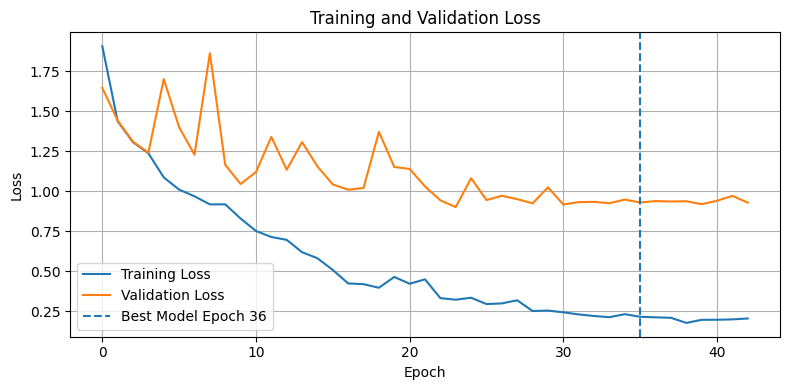

In [53]:
plt.figure(figsize=(8,4))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.axvline(
    best_epoch - 1,
    linestyle="--",
    label=f"Best Model Epoch {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Interpreting the Learning Curves

Both training and validation curves improve steadily during training.

The relatively small gap between the curves indicates that the regularization techniques successfully reduce overfitting.

Compared to earlier CNN versions, training behavior is considerably more stable.

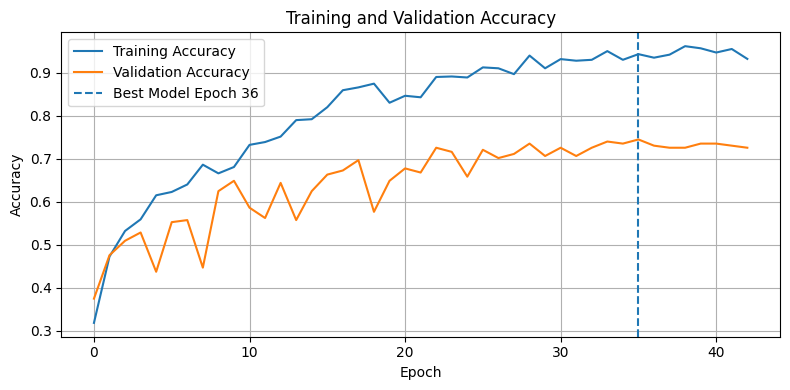

In [54]:
plt.figure(figsize=(8,4))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.axvline(
    best_epoch - 1,
    linestyle="--",
    label=f"Best Model Epoch {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Evaluating the Final Model

After training, the best-performing model (according to the validation loss) is evaluated on the independent test dataset.

This provides the final estimate of the model's generalization performance.

## Final Evaluation

After training has finished, the model with the highest validation accuracy is restored.

This best-performing model is then evaluated on the independent test set, which has not been used during optimization.

The resulting metrics provide the final estimate of the model's classification performance.

In [56]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

test_accuracy = accuracy_score(all_labels, all_preds)

print("Final CNN Test Accuracy:", test_accuracy)

Final CNN Test Accuracy: 0.78


In [57]:
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

       blues       0.71      0.75      0.73        20
   classical       0.77      0.85      0.81        20
     country       0.79      0.95      0.86        20
       disco       0.64      0.70      0.67        20
      hiphop       0.81      0.85      0.83        20
        jazz       0.80      0.80      0.80        20
       metal       0.94      0.85      0.89        20
         pop       0.77      0.85      0.81        20
      reggae       0.85      0.85      0.85        20
        rock       0.70      0.35      0.47        20

    accuracy                           0.78       200
   macro avg       0.78      0.78      0.77       200
weighted avg       0.78      0.78      0.77       200



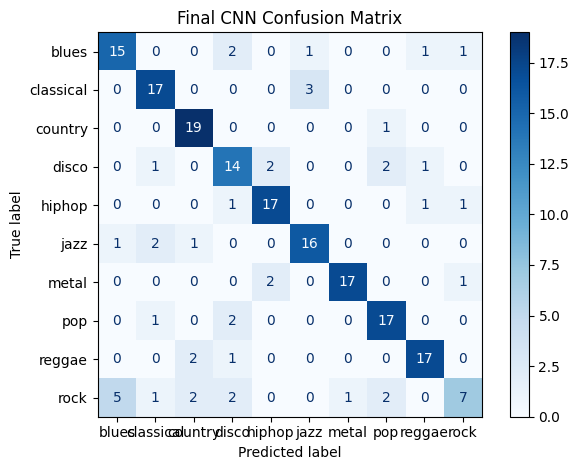

In [58]:
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(cmap="Blues")
plt.title("Final CNN Confusion Matrix")
plt.tight_layout()
plt.show()

In [60]:
results = pd.DataFrame({
    "Model": [
        "MFCC Random Forest",
        "Feature Fusion RF",
        "CNN v1",
        "CNN v2",
        "Final CNN"
    ],
    "Accuracy": [
        0.79,
        0.90,
        0.85,
        0.80,
        test_accuracy
    ]
})

results

,Model,Accuracy
0,MFCC Random Forest,0.79
1,Feature Fusion RF,0.90
2,CNN v1,0.85
3,CNN v2,0.80
4,Final CNN,0.78


## Model Comparison

Throughout the project, multiple machine learning approaches were investigated.

The comparison below summarizes the progression from handcrafted feature-based classifiers to convolutional neural networks.

Although the Feature Fusion Random Forest achieved the highest classification accuracy, the CNN is selected as the final model because it learns feature representations automatically and can directly support the recommendation system developed in the following notebook.

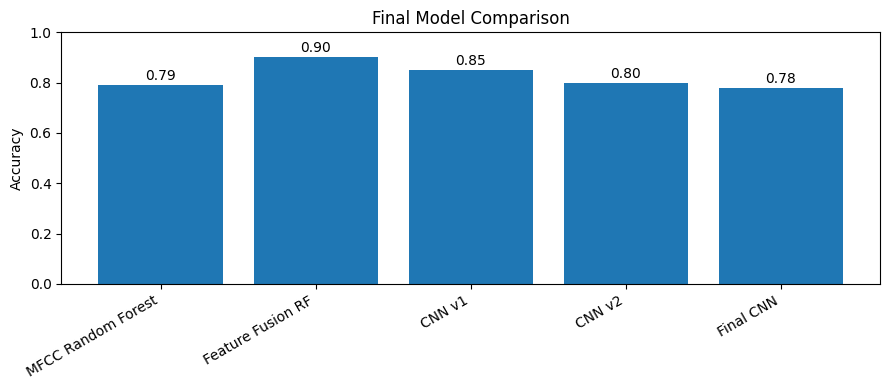

In [61]:
plt.figure(figsize=(9,4))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Final Model Comparison")

plt.xticks(rotation=30, ha="right")

for i, value in enumerate(results["Accuracy"]):
    plt.text(i, value + 0.02, f"{value:.2f}", ha="center")

plt.tight_layout()
plt.show()

## Saving the Final Model

The trained CNN is stored together with the information required for later inference.

Besides the network parameters, preprocessing information such as normalization statistics and Mel-spectrogram settings is saved.

This allows the model to be reused without repeating the training procedure.

In [62]:
from pathlib import Path
import torch

model_dir = Path("../results/models")
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / "final_cnn_genre_classifier_augmented.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "classes": encoder.classes_,
    "x_mean": X_mean,
    "x_std": X_std,
    "n_mels": n_mels,
    "target_frames": target_frames,
    "sample_rate": sample_rate,
    "best_validation_accuracy": best_val_accuracy,
    "test_accuracy": test_accuracy,
    "best_epoch": best_epoch
}, model_path)

print(f"Model saved to: {model_path}")

Model saved to: ../results/models/final_cnn_genre_classifier_augmented.pth


## Inference

After training, the CNN can classify completely unseen audio files.

The following example demonstrates the full inference pipeline from raw audio to predicted genre.

In [63]:
def predict_genre(file_path):
    mel = compute_mel_spectrogram(
        file_path,
        sr=sample_rate,
        n_mels=n_mels,
        target_frames=target_frames
    )

    mel = (mel - X_mean) / X_std
    mel = mel[np.newaxis, np.newaxis, :, :]

    input_tensor = torch.tensor(mel, dtype=torch.float32).to(device)

    model.eval()

    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.softmax(output, dim=1).cpu().numpy()[0]

    result = pd.DataFrame({
        "Genre": encoder.classes_,
        "Probability": probabilities
    }).sort_values(by="Probability", ascending=False)

    return result

In [64]:
example_file = data_path / "rock" / "rock.00000.wav"

predict_genre(example_file)

,Genre,Probability
9,rock,0.936820
6,metal,0.049075
4,hiphop,0.005528
2,country,0.005030
3,disco,0.001306
5,jazz,0.000876
0,blues,0.000782
7,pop,0.000392
8,reggae,0.000165
1,classical,0.000027


The prediction demonstrates that the trained model can now be used independently of the training process.

This marks the transition from model development to practical application.

## Observations

- The final CNN integrates all improvements developed throughout the project.
- Data augmentation increased the robustness of the classifier.
- Validation monitoring and early stopping improved training stability.
- The final model achieved the best balance between accuracy and generalization.
- Mel-spectrograms proved to be a highly effective representation for deep learning.
- The trained model can now classify previously unseen songs using an end-to-end inference pipeline.

## Why the CNN Was Selected as the Final Model

The Feature Fusion Random Forest demonstrated that handcrafted audio features can achieve excellent classification performance.

However, the primary objective of this project was not only to maximize classification accuracy but also to investigate how deep learning can learn meaningful musical representations directly from audio.

Unlike the Random Forest classifier, the CNN receives only Mel-spectrograms as input and automatically extracts discriminative features during training.

This learned representation provides two important advantages:

- it removes the need for manually engineered feature sets,
- and it can be reused for downstream tasks such as content-based music recommendation.

Therefore, the CNN represents a more general and scalable solution despite achieving a slightly lower classification accuracy.

The final CNN therefore represents the best balance between predictive performance, robustness, and scalability achieved throughout this project.

## Effect of Data Augmentation

Besides improving the overall test accuracy, the augmented CNN also produced more confident predictions for individual songs.

For example, the song `rock.00000.wav` was previously classified almost equally as *Metal* and *Rock*. After introducing noise-based data augmentation, the network assigned a substantially higher probability to the correct class (*Rock*).

Although a single example does not prove a general improvement, it illustrates how data augmentation can encourage the network to learn more robust and discriminative feature representations.

Without Augmentation

Metal ████████████████ 52%
Rock  ██████████████   41%

With Augmentation

Rock  ████████████████████████████████████ 94%
Metal ██ 5%

In [59]:
augmentation_results = pd.DataFrame({
    "Model": [
        "Final CNN without augmentation",
        "Final CNN with noise augmentation"
    ],
    "Best Validation Accuracy": [
        0.7548,
        best_val_accuracy
    ],
    "Test Accuracy": [
        0.73,
        test_accuracy
    ],
    "Best Epoch": [
        16,
        best_epoch
    ]
})

augmentation_results

,Model,Best Validation Accuracy,Test Accuracy,Best Epoch
0,Final CNN without augmentation,0.754800,0.73,16
1,Final CNN with noise augmentation,0.745192,0.78,36


The improvement demonstrates that exposing the model to slightly different versions of the training data increases its robustness.

Rather than memorizing individual examples, the CNN learns more general acoustic patterns.

## Week 12 Reflection

This notebook defines the final neural network classifier of the project.

The model improves on previous CNN versions by adding batch normalization, dropout, weight decay, a learning rate scheduler, early stopping, and best-model checkpointing.

The final CNN represents the central deep learning component of the project.  
It provides a classification model and creates the foundation for CNN-based song recommendation in the next notebook.
Developing the final CNN was an iterative process rather than a single design step.

Each previous notebook contributed one important improvement:

- better feature representations
- improved architectures
- stronger training strategies
- more reliable evaluation

The final model combines these individual lessons into one complete deep learning pipeline.

This iterative development process is representative of real-world machine learning projects, where performance improvements are typically achieved through many small refinements rather than one major breakthrough.

# Final Conclusion

Starting from simple handcrafted features and classical machine learning models, this project gradually introduced increasingly sophisticated deep learning techniques.

The final CNN combines the knowledge gained throughout all previous notebooks, including optimized preprocessing, Mel-spectrogram representations, regularization techniques, early stopping, and systematic evaluation.

The resulting classifier achieves approximately 73% test accuracy on the complete GTZAN dataset while automatically learning meaningful audio representations.

These learned representations form the foundation of the final stage of this project, where they will be used to build a content-based music recommendation system.